# Cluster selection — Phase 1 (GBDT)

**Problem.** Vertex-timing error in Z+jets is dominated by *cluster selection*, not clustering:
a cluster within 60 ps of truth exists in ~87% of events, but the best hand-made score
(TRKPTZ) picks it only ~62% of the time. Hand-designed reweightings of the WAVeS jet term
(LOJO / JETCAP / KERNEL) all failed — LOJO changed the decision on ~4700 recoverable events
and was right 47.7% of the time, i.e. a coin flip. So we learn the selector instead.

**Framing.** This is *ranking within an event*, not per-cluster classification. That distinction
matters: an earlier attempt at absolute per-cluster "is this cluster trustworthy?" failed, because
a confidently-wrong cluster looks identical to a right one in reco-only features. Relative
comparison inside one event is a different — and easier — question.

**Constraint.** No `lightgbm`/`xgboost` in this kernel, so there is no listwise objective available.
We use `HistGradientBoosting` (NaN-native) with **within-event context features** to inject the
relative information, and take argmax/argmin *within event* at inference. Three formulations:

| formulation | target | pick |
|---|---|---|
| **A** | binary: is the truth-closest cluster | argmax proba |
| **B** | binary: within 60 ps of truth | argmax proba |
| **C** | regress log1p(&#124;Δt&#124;) | **argmin** prediction |

**Figure of merit is the physics metric, not AUC**: core fraction (selected cluster within
±60 ps of truth), reported against the TRKPTZ baseline and the oracle ceiling.

## 1. Setup

In [1]:
import glob, os, warnings
import numpy as np, pandas as pd, uproot
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")

# --- where the exporter's ROOT files live -----------------------------------
# condor writes <repo>/<sample>/<sample>_training.root; the local run writes
# figs/hists/training.root. Adjust SEARCH_DIRS if you staged them elsewhere.
SEARCH_DIRS = [".", "..", "../..", "figs/hists", "../figs/hists"]
SAMPLES     = ["vbf", "zjets", "dijet"]

PASS_PS   = 60.0     # the physics window (PASS_SIGMA in clustering_constants.h)
EVT       = ["sample_id", "event_num"]   # ranking group key
RANDOM    = 0

SAMPLE_NAME = {0.0: "vbf", 1.0: "zjets", 2.0: "dijet", 3.0: "local"}

def find_files():
    hits = {}
    for d in SEARCH_DIRS:
        for s in SAMPLES:
            for p in glob.glob(os.path.join(d, s, f"{s}_training.root")) + \
                     glob.glob(os.path.join(d, f"{s}_training.root")):
                hits.setdefault(s, os.path.abspath(p))
        for p in glob.glob(os.path.join(d, "training.root")):
            hits.setdefault("local", os.path.abspath(p))
    return hits

FILES = find_files()
for k, v in FILES.items():
    print(f"  found {k:6s} -> {v}")
if not FILES:
    print("\\n!! No training ROOT files found. Run:  ./export_training_data --sample=<s>")

  found vbf    -> /home/mcardiff/project/vertex_timing/figs/hists/vbf_training.root
  found zjets  -> /home/mcardiff/project/vertex_timing/figs/hists/zjets_training.root
  found dijet  -> /home/mcardiff/project/vertex_timing/figs/hists/dijet_training.root

## 2. Load

In [2]:
def load(files):
    parts = []
    for name, path in files.items():
        df = uproot.open(path)["clusters"].arrays(library="pd")
        parts.append(df)
        print(f"  {name:6s} {len(df):>8,} cluster rows   "
              f"{df.groupby(EVT).ngroups:>7,} events   ({path})")
    return pd.concat(parts, ignore_index=True)

df = load(FILES)
df["abs_dt"] = df["delta_t"].abs()
print(f"\ntotal {len(df):,} rows / {df.groupby(EVT).ngroups:,} events / {df.shape[1]} columns")

  vbf    3,487,533 cluster rows   620,101 events   (/home/mcardiff/project/vertex_timing/figs/hists/vbf_training.root)  zjets   378,296 cluster rows    67,074 events   (/home/mcardiff/project/vertex_timing/figs/hists/zjets_training.root)  dijet   545,553 cluster rows    94,605 events   (/home/mcardiff/project/vertex_timing/figs/hists/dijet_training.root)
total 4,411,382 rows / 781,780 events / 96 columns

## 3. Labels and baselines

Labels come from `delta_t` (cluster time − truth HS time), which is the **target**, never a feature.
`is_best` = the truth-closest cluster in the event; `within60` = inside the physics window
(multi-positive — several clusters can qualify).

In [4]:
g = df.groupby(EVT, sort=False)["abs_dt"]
df["is_best"]  = (df["abs_dt"] == g.transform("min")).astype(int)
df["within60"] = (df["abs_dt"] < PASS_PS).astype(int)
# an event is RECOVERABLE if any cluster is inside the window; a "win" on an
# unrecoverable event is luck, so we report both inclusive and conditional numbers
df["recoverable"] = (g.transform("min") < PASS_PS).astype(int)

def select_metric(frame, col, higher_is_better=True):
    """Pick one cluster per event by `col`, return (core fraction, median |dt|)."""
    s = frame[col]
    s = s.fillna(-np.inf if higher_is_better else np.inf)
    idx = s.groupby([frame[c] for c in EVT], sort=False)
    idx = idx.idxmax() if higher_is_better else idx.idxmin()
    sel = frame.loc[idx.to_numpy()]
    return 100.0 * (sel["abs_dt"] < PASS_PS).mean(), sel["abs_dt"].median()

def report(frame, rows, title):
    print(f"\n{title}   ({frame.groupby(EVT).ngroups:,} events)")
    print(f"  {'selector':26s} {'core<60ps':>10s} {'median|dt|':>11s}")
    print("  " + "-" * 50)
    for name, col, hib in rows:
        cf, md_ = select_metric(frame, col, hib)
        print(f"  {name:26s} {cf:9.1f}% {md_:10.1f} ps")

BASELINES = [("oracle (truth-closest)", "abs_dt", False),
             ("TRKPTZ", "trkptz_score", True),
             ("WAVeS",  "waves_score",  True),
             ("sumpt",  "sumpt",        True)]
report(df, BASELINES, "ALL SAMPLES")
for sid, sub in df.groupby("sample_id"):
    report(sub, BASELINES, f"sample = {SAMPLE_NAME.get(sid, sid)}")


ALL SAMPLES   (781,780 events)
  selector                    core<60ps  median|dt|
  --------------------------------------------------  oracle (truth-closest)          97.7%       11.1 ps  TRKPTZ                          87.3%       12.2 ps  WAVeS                           87.5%       12.2 ps  sumpt                           85.9%       12.4 ps
sample = vbf   (620,101 events)
  selector                    core<60ps  median|dt|
  --------------------------------------------------  oracle (truth-closest)          98.2%       10.7 ps  TRKPTZ                          90.1%       11.5 ps  WAVeS                           90.7%       11.4 ps  sumpt                           89.1%       11.6 ps

sample = zjets   (67,074 events)
  selector                    core<60ps  median|dt|
  --------------------------------------------------
  oracle (truth-closest)          92.5%       17.8 ps
  TRKPTZ                          62.0%       31.3 ps
  WAVeS                           60.0%       33.8 ps
 

## 4. Features

Three things happen here:

1. **Leakage guard** — every `truth_*` column, `delta_t`/`abs_dt` and the derived labels are
   dropped from `X`. `sample_id` is dropped too, so the cross-topology test in §8 is honest.

   > ⚠️ **The prefix test alone is not sufficient on older files.** The exporter only started
   > writing `nHGTDPrimaryHits` under a `truth_` prefix in `e507e76`; any `*_training.root`
   > produced before that re-export still carries the bare name `mean_nhgtd_primary`, which
   > `startswith("truth_")` cannot see. `TRUTH_ALIASES` below lists the pre-rename names so the
   > guard is correct for **both** vintages, and the cell prints a warning when it fires.
   > A closing `assert` fails loudly rather than training on a truth column.

2. **Degenerate columns** are detected and removed automatically (all-NaN or constant). This
   catches the known ones without hard-coding: `frac_valid_time`/`n_valid_time`/`sumpt_valid_time`
   are degenerate by construction (clustering already requires valid times), `mean/min_quality`
   is constant in these samples, and the lepton block is empty outside Z+jets.
3. **By-design exclusions** (`EXCLUDE_BY_DESIGN`) — features that are legitimate reco but that we
   refuse on scientific grounds:
   - the **HGTD block** (`hgtd_time`, `hgtd_valid`, `hgtd_time_res`, `dt_cluster_to_hgtd`) all derive
     from `RecoVtx_time`, i.e. the *old algorithm's output*. The point of this work is to replace
     that algorithm, so depending on it would be circular. Measured cost: ~0.5 points.
     `dt_cluster_to_hgtd` has ρ = **+0.96** with `abs_dt` — it is very nearly the target.
   - `nHGTDPrimaryHits` — **confirmed truth, and confirmed label leakage.** Athena builds it from
     a per-hit `m_isprime` flag, commented *"keep which of the hits associated in reco were
     primary hits (truth info!)"*. It counts how many of a track's HGTD hits genuinely came from
     that track's own truth particle — which is *directly* a statement about whether the track's
     **time** is right, and therefore about the label.

     > **Two earlier arguments that it was harmless were both wrong, and are worth recording
     > because the failure modes are generic:**
     >
     > 1. *"Correlation with `truth_is_hs` is only +0.09."* Wrong target. The label is time
     >    accuracy, not HS-ness. Measured on the local VBF file: ρ = −0.065 with `truth_purity`
     >    but **+0.21 with `is_best`, +0.22 with `within60`, and −0.44 with `abs_dt`**. It is
     >    nearly orthogonal to the quantity I tested and strongly aligned with the actual label.
     > 2. *"Drop-column ablation says its contribution is exactly 0.0."* Right test, wrong
     >    sample. On VBF it **is** 0.0 (92.5% with and without, reproduced) because VBF has only
     >    ~8 points of headroom and `sumpt`/`is_max_trkptz` already cover it. On Z+jets, where
     >    TRKPTZ delivers 62% against a 92% ceiling, no legitimate feature covers that ground and
     >    the model leans on the truth column hard: **80%+ with it, 66% without.** A pooled or
     >    VBF-only ablation cannot see this — hence the per-sample ablation in §9b.

4. **Within-event normalization** — the load-bearing step given we have no listwise loss. For a
   curated set of features we add `_ratio_to_max` and `_rank` *within the event*, which is what
   lets a per-cluster model express "best of what's available here".

In [3]:
LABELS = ["is_best", "within60", "recoverable"]
# Ordering guard: this cell must run AFTER §3, which creates the label columns.
# If it runs first they are simply absent from df -- they cannot leak into feat,
# but the "held out" count silently drops and the guard is then passing by
# accident rather than by construction. (Observed: run 4 executed §4 at In[3]
# and §3 at In[4].)
assert all(c in df.columns for c in LABELS), \
    f"run \u00a73 first -- missing {[c for c in LABELS if c not in df.columns]}"

LEAK = [c for c in df.columns if c.startswith("truth_")] + \
       ["delta_t", "abs_dt"] + LABELS
IDS  = ["event_num", "cluster_idx", "sample_id", "weight"]

# Pre-rename aliases. The exporter emits these under the truth_ prefix as of
# e507e76, but a ROOT file written BEFORE that re-export still has the old bare
# name, which the prefix test above cannot catch -- and e507e76 also removed the
# manual exclusion, so on an old file the column silently re-enters the features.
# Listing the old names keeps the guard correct for both vintages; on a
# re-exported file they simply match nothing. Safe to delete only once every
# training file on disk is post-rename.
TRUTH_ALIASES = ["mean_nhgtd_primary", "nhgtd_primary"]
_stale = sorted(set(TRUTH_ALIASES) & set(df.columns))
if _stale:
    print("!! PRE-RENAME FILE: " + ", ".join(_stale) + " present under the old bare name.")
    print("   Excluded via TRUTH_ALIASES (the truth_ prefix test does not see them).")
    print("   Re-run util/export_training_data.cxx to emit them truth_-prefixed.\n")
LEAK += TRUTH_ALIASES

# Legitimate reco, but excluded deliberately -- see the notes above. Flip
# USE_HGTD_FEATURES to True only to quantify what the old-algorithm prior is worth.
USE_HGTD_FEATURES = False
HGTD_BLOCK = ["hgtd_time", "hgtd_valid", "hgtd_time_res", "dt_cluster_to_hgtd", "mean_nhgtd_primary"]
# (mean_nhgtd_primary is no longer listed here: the exporter now writes it as
#  truth_mean_nhgtd_primary, so the truth_ guard above catches it automatically.)
EXCLUDE_BY_DESIGN = [] if USE_HGTD_FEATURES else list(HGTD_BLOCK)

# Curated list for within-event normalization: continuous, physically meaningful,
# and plausibly comparative. (Normalizing all ~90 would triple the width for little gain.)
NORMALIZE = ["sumpt", "sumpt2", "maxpt", "n_tracks", "cluster_time_sigma",
             "time_chi2_ndf", "delta_z_resunits", "z_chi2_ndf", "mean_nhgtd",
             "trkptz_score", "waves_score", "frac_pt_in_fwdjet", "lead_pt_frac",
             "dz_to_lepton_signif", "sumpt_in_fwdjet"]

def add_event_context(frame):
    frame = frame.copy()
    gb = frame.groupby(EVT, sort=False)
    for c in NORMALIZE:
        if c not in frame.columns:
            continue
        mx = gb[c].transform("max")
        frame[f"{c}_ratio_to_max"] = np.where(np.abs(mx) > 0, frame[c] / mx, np.nan)
        frame[f"{c}_rank"] = gb[c].rank(ascending=False, method="min")
    return frame

df = add_event_context(df)

DROP = set(LEAK) | set(IDS) | set(EXCLUDE_BY_DESIGN)
feat = [c for c in df.columns if c not in DROP]
# auto-drop degenerate columns (evaluated on the full set)
degen = [c for c in feat
         if df[c].isna().all() or df[c].nunique(dropna=True) <= 1]
feat = [c for c in feat if c not in degen]

# Fail loudly rather than train on a truth column: cheap, and the two mechanisms
# above (prefix + alias) are exactly the kind of thing that rots when the schema moves.
_bad = [c for c in feat if c.startswith("truth_") or c in set(TRUTH_ALIASES)]
assert not _bad, f"TRUTH LEAKED INTO FEATURES: {_bad}"

print(f"dropped {len(degen)} degenerate columns:")
for c in degen: print("   ", c)
print(f"\nexcluded by design: {sorted(set(EXCLUDE_BY_DESIGN) & set(df.columns))}")
print(f"truth/label columns held out: {len(set(LEAK) & set(df.columns))}")
print(f"{len(feat)} features -> X")

!! PRE-RENAME FILE: mean_nhgtd_primary present under the old bare name.
   Excluded via TRUTH_ALIASES (the truth_ prefix test does not see them).
   Re-run util/export_training_data.cxx to emit them truth_-prefixed.
dropped 3 degenerate columns:
    frac_valid_time
    mean_quality
    min_quality

excluded by design: ['dt_cluster_to_hgtd', 'hgtd_time', 'hgtd_time_res', 'hgtd_valid', 'mean_nhgtd_primary']
truth/label columns held out: 6
107 features -> X

## 5. Split

Split **by event**, never by row — two clusters from the same event must not straddle
train/test, or the model sees the answer. Events are the effective sample size here
(~N_events, not N_rows).

In [5]:
rng = np.random.default_rng(RANDOM)
ev  = df[EVT].drop_duplicates().reset_index(drop=True)
ev["fold"] = rng.random(len(ev))
df2 = df.merge(ev, on=EVT, how="left")
train = df2[df2.fold <  0.7].copy()
test  = df2[df2.fold >= 0.7].copy()
print(f"train {train.groupby(EVT).ngroups:,} events / {len(train):,} rows")
print(f"test  {test.groupby(EVT).ngroups:,} events / {len(test):,} rows")

train 546,638 events / 3,083,236 rows
test  235,142 events / 1,328,146 rows

## 6. Train — formulations A, B, C

`HistGradientBoosting` handles NaN natively, which matters: `time_chi2_ndf` is NaN for the
~32% of clusters with a single timed track, and `hgtd_*` is NaN wherever `RecoVtx_time` is
missing (~8% in VBF, ~55% in Z+jets). **Never impute those with 0** — 0.0 is a legitimate time.

In [6]:
# max_iter raised from 400 -> 2000: the first full run reported "iterations used: 400"
# for all three models, i.e. they hit the ceiling and early stopping never fired, so
# they were underfit. Early stopping is on, so a high ceiling costs only time.
COMMON = dict(max_iter=2000, learning_rate=0.06, max_leaf_nodes=31,
              min_samples_leaf=50, l2_regularization=1.0,
              early_stopping=True, validation_fraction=0.15,
              random_state=RANDOM)

# Optional: upweight the smaller samples so zjets (8.6% of events but where 26 of the
# ~31 available points live) is not drowned by VBF. The transfer matrix suggests the
# gain is small (~0.2 pts) since vbf-trained already transfers well -- off by default
# so results stay comparable to the unweighted run.
BALANCE_SAMPLES = False
def sample_weights(frame):
    if not BALANCE_SAMPLES:
        return None
    n = frame.groupby("sample_id")["sample_id"].transform("size")
    return (len(frame) / (frame["sample_id"].nunique() * n)).to_numpy()

SW = sample_weights(train)
models, preds = {}, {}

# A — is this the truth-closest cluster?
mA = HistGradientBoostingClassifier(**COMMON).fit(train[feat], train["is_best"], sample_weight=SW)
test["scoreA"] = mA.predict_proba(test[feat])[:, 1]
models["A is_best"] = mA

# B — is this cluster inside the 60 ps window? (multi-positive)
mB = HistGradientBoostingClassifier(**COMMON).fit(train[feat], train["within60"], sample_weight=SW)
test["scoreB"] = mB.predict_proba(test[feat])[:, 1]
models["B within60"] = mB

# C — regress log1p(|dt|); log compresses a very long tail. Pick the MINIMUM.
mC = HistGradientBoostingRegressor(**COMMON).fit(train[feat], np.log1p(train["abs_dt"]), sample_weight=SW)
test["scoreC"] = mC.predict(test[feat])
models["C reg log|dt|"] = mC

for k, m in models.items():
    print(f"{k:16s} iterations used: {m.n_iter_}")

A is_best        iterations used: 1073
B within60       iterations used: 1149
C reg log|dt|    iterations used: 1488

## 7. Results (test set)

In [9]:
ROWS = [("oracle (ceiling)", "abs_dt", False),
        ("TRKPTZ (baseline)", "trkptz_score", True),
        ("WAVeS", "waves_score", True),
        ("A  is_best",  "scoreA", True),
        ("B  within60", "scoreB", True),
        ("C  reg |dt|", "scoreC", False)]

def table(frame, title):
    print(f"\n=== {title}  ({frame.groupby(EVT).ngroups:,} events) ===")
    res = {n: select_metric(frame, c, h) for n, c, h in ROWS}
    base = res["TRKPTZ (baseline)"][0]
    ceil = res["oracle (ceiling)"][0]
    print(f"  {'selector':20s} {'core<60ps':>10s} {'median|dt|':>11s} {'vs TRKPTZ':>10s} {'gap closed':>11s}")
    print("  " + "-" * 68)
    for n, _, _ in ROWS:
        cf, md_ = res[n]
        d   = "" if n.startswith(("oracle", "TRKPTZ")) else f"{cf-base:+.1f} pts"
        gap = "" if n.startswith(("oracle", "TRKPTZ")) or ceil <= base \
              else f"{100*(cf-base)/(ceil-base):.0f}%"
        print(f"  {n:20s} {cf:9.1f}% {md_:10.1f} ps {d:>10s} {gap:>11s}")
    return res

_ = table(test, "ALL SAMPLES")
for sid, sub in test.groupby("sample_id"):
    _ = table(sub, f"sample = {SAMPLE_NAME.get(sid, sid)}")

# conditional on the event being recoverable at all -- isolates selection skill
_ = table(test[test.recoverable == 1], "RECOVERABLE EVENTS ONLY")


=== ALL SAMPLES  (235,142 events) ===  selector              core<60ps  median|dt|  vs TRKPTZ  gap closed
  --------------------------------------------------------------------
  oracle (ceiling)          97.6%       11.2 ps                       
  TRKPTZ (baseline)         87.3%       12.2 ps                       
  WAVeS                     87.5%       12.2 ps   +0.3 pts          3%
  A  is_best                90.2%       11.8 ps   +2.9 pts         28%
  B  within60               90.3%       11.8 ps   +3.0 pts         29%
  C  reg |dt|               90.0%       11.8 ps   +2.7 pts         26%

=== sample = vbf  (186,342 events) ===  selector              core<60ps  median|dt|  vs TRKPTZ  gap closed
  --------------------------------------------------------------------
  oracle (ceiling)          98.2%       10.8 ps                       
  TRKPTZ (baseline)         90.1%       11.6 ps                       
  WAVeS                     90.7%       11.5 ps   +0.7 pts          8%
  A 

## 8. Cross-topology transfer — the risk that matters most

This study's central finding is that **VBF and Z+jets prefer opposite behaviour**: the WAVeS jet
term helps VBF (+1.8 pts) and hurts Z+jets (−3.3 pts); LOJO is −10.2 on VBF and −0.4 on Z+jets.
A model trained on one topology can therefore learn a rule that is *actively wrong* on another.

`sample_id` is excluded from the features, so this matrix measures genuine transfer.
Read the off-diagonal: if train-VBF/test-Z+jets collapses, the selector is topology-specific and
we need either a mixed training set (the diagonal-plus row) or a per-topology model.

In [7]:
def core_of(frame, col, hib=True):
    return select_metric(frame, col, hib)[0]

sids = sorted(df2["sample_id"].unique())
if len(sids) > 1:
    hdr = "train / test".rjust(14) + "".join(f"{SAMPLE_NAME.get(s,s):>12s}" for s in sids)
    print(hdr + f"{'MIXED':>12s}")
    for tr in list(sids) + ["mixed"]:
        tr_df = train if tr == "mixed" else train[train.sample_id == tr]
        m = HistGradientBoostingClassifier(**COMMON).fit(tr_df[feat], tr_df["is_best"])
        label = "mixed" if tr == "mixed" else SAMPLE_NAME.get(tr, tr)
        line = f"{label:>14s}"
        for te in sids:
            sub = test[test.sample_id == te].copy()
            sub["p"] = m.predict_proba(sub[feat])[:, 1]
            line += f"{core_of(sub,'p'):11.1f}%"
        allsub = test.copy(); allsub["p"] = m.predict_proba(allsub[feat])[:, 1]
        line += f"{core_of(allsub,'p'):11.1f}%"
        print(line)
    print("\nreference (TRKPTZ baseline, same test sets):")
    line = f"{'TRKPTZ':>14s}"
    for te in sids:
        line += f"{core_of(test[test.sample_id==te],'trkptz_score'):11.1f}%"
    print(line + f"{core_of(test,'trkptz_score'):11.1f}%")
else:
    print("only one sample loaded — run the other --sample exports to fill this matrix")

  train / test         vbf       zjets       dijet       MIXED           vbf       92.9%       65.2%       89.3%       90.1%         zjets       92.2%       66.1%       89.1%       89.5%         dijet       92.6%       65.3%       89.1%       89.8%         mixed       92.9%       66.2%       89.4%       90.2%

reference (TRKPTZ baseline, same test sets):        TRKPTZ       90.1%       62.1%       87.0%       87.3%

## 9. What is the model using?

Permutation importance on the physics metric's own quantity (not AUC). Two things to check:

- **Is it just relearning TRKPTZ?** `trkptz_score` and its `_ratio_to_max` sitting alone at the
  top with everything else flat would mean no real gain — compare the §7 numbers to the baseline.
- **Which topology signals matter?** the jet-association block is where VBF and Z+jets disagree.

> ⚠️ **Permutation importance overstates features with correlated substitutes.** It measures how
> much the *fitted model* leans on a column, not how much information the column carries. Use it
> to generate hypotheses; use the **per-sample ablation in §9b** to decide anything.
>
> The cautionary case: `mean_nhgtd_primary` scored 0.279 here, 40x the next feature. That reading
> was *correct* — it really was doing the work — but it was dismissed because a VBF drop-column
> ablation returned 0.0. Both readings were true and the conclusion was still wrong, because the
> ablation was run on the sample where the feature is redundant. **A high importance score with a
> zero ablation is a signal to ablate on the hard sample, not a signal that the feature is inert.**

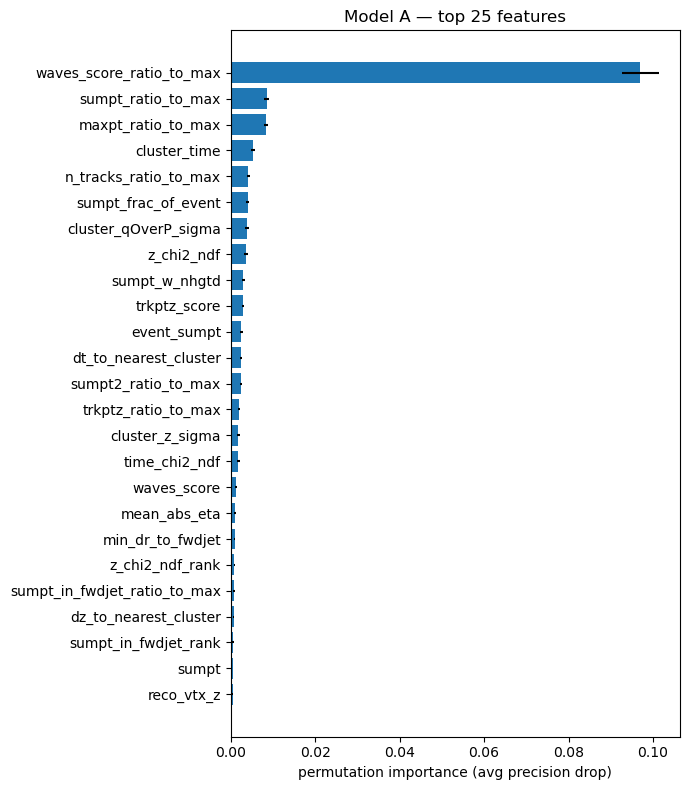

top 25:
   0.09699  waves_score_ratio_to_max
   0.00854  sumpt_ratio_to_max
   0.00844  maxpt_ratio_to_max
   0.00524  cluster_time
   0.00420  n_tracks_ratio_to_max
   0.00401  sumpt_frac_of_event
   0.00390  cluster_qOverP_sigma
   0.00352  z_chi2_ndf
   0.00299  sumpt_w_nhgtd
   0.00293  trkptz_score
   0.00254  event_sumpt
   0.00247  dt_to_nearest_cluster
   0.00245  sumpt2_ratio_to_max
   0.00206  trkptz_ratio_to_max
   0.00180  cluster_z_sigma
   0.00179  time_chi2_ndf
   0.00125  waves_score
   0.00101  mean_abs_eta
   0.00091  min_dr_to_fwdjet
   0.00089  z_chi2_ndf_rank
   0.00079  sumpt_in_fwdjet_ratio_to_max
   0.00070  dz_to_nearest_cluster
   0.00051  sumpt_in_fwdjet_rank
   0.00048  sumpt
   0.00046  reco_vtx_z

In [15]:
sub = test.sample(min(20000, len(test)), random_state=RANDOM)
imp = permutation_importance(mA, sub[feat], sub["is_best"], n_repeats=5,
                             random_state=RANDOM, scoring="average_precision")
order = np.argsort(imp.importances_mean)[::-1][:25]
plt.figure(figsize=(7, 8))
plt.barh([feat[i] for i in order][::-1], imp.importances_mean[order][::-1],
         xerr=imp.importances_std[order][::-1])
plt.xlabel("permutation importance (avg precision drop)")
plt.title("Model A — top 25 features")
plt.tight_layout(); plt.show()

print("top 25:")
for i in order:
    print(f"  {imp.importances_mean[i]:8.5f}  {feat[i]}")

### 9b. Drop-column ablation — per sample, not pooled

Retrains without a group of features and re-measures the physics metric. Slower than permutation
importance, but it answers what we actually care about: *would we lose anything by not having this?*

**Run it per sample.** A pooled ablation is dominated by whichever sample has the most events and
the least headroom, and that is exactly how a leaking feature stayed hidden here: on VBF (90% →
98% ceiling) dropping `mean_nhgtd_primary` cost **0.0 points**, because `sumpt`/`is_max_trkptz`
already carry that ground. On Z+jets (62% → 92% ceiling) nothing legitimate carries it, and the
same column was worth **~14 points**. One number per sample, or you learn nothing.

The last row is a **leakage sentinel**: it keeps *only* the suspect column plus the two hand-made
scores. If a single feature can move the metric on its own, you want to know before it ends up in
a talk.

In [16]:
ABLATE = {
    "(none - reference)":      [],
    "jet-association block":   [c for c in feat if "fwdjet" in c or "ghost" in c],
    "timing-coherence block":  [c for c in feat if "tpull" in c or "chi2" in c or "timeRes" in c],
    "within-event context":    [c for c in feat if c.endswith(("_ratio_to_max", "_rank"))],
    "hand-made scores":        [c for c in feat if "trkptz" in c or "waves" in c],
}

# COST. This is 5 ablation fits + 1 floor + one per SUSPECT column, where §6 fits
# just 3 -- at COMMON's max_iter it does not finish in a sitting (run 3 was
# interrupted after printing only the header). Ablation is a RELATIVE measure, so
# cap the iterations: the absolute core fractions below will sit slightly under the
# §7 table, and only differences WITHIN this table are meaningful. Raise
# ABLATE_MAX_ITER (or set it to COMMON["max_iter"]) if you want absolutes too.
ABLATE_MAX_ITER = 300
ABLATE_COMMON = {**COMMON, "max_iter": ABLATE_MAX_ITER}
print(f"(ablation fits capped at max_iter={ABLATE_MAX_ITER}; compare within this "
      f"table only, not against \u00a77)\n")

import time
SIDS = sorted(test["sample_id"].unique())
names = [SAMPLE_NAME.get(s, s) for s in SIDS]

hdr = f"{'dropped':26s} {'nfeat':>5s}" + "".join(f"{n:>10s}" for n in names) + f"{'POOLED':>10s}"
print(hdr); print("-" * len(hdr))

rows = {}
for name, drop in ABLATE.items():
    f = [c for c in feat if c not in set(drop)]
    t0 = time.time()
    m = HistGradientBoostingClassifier(**ABLATE_COMMON).fit(
        train[f], train["is_best"], sample_weight=sample_weights(train))
    t2 = test.copy(); t2["p"] = m.predict_proba(t2[f])[:, 1]
    per = [select_metric(t2[t2.sample_id == s], "p")[0] for s in SIDS]
    pooled = select_metric(t2, "p")[0]
    rows[name] = per + [pooled]
    print(f"{name:26s} {len(f):5d}" + "".join(f"{v:9.1f}%" for v in per + [pooled])
          + f"   [{time.time()-t0:.0f}s]", flush=True)

# deltas vs the reference row -- this is the number to read
ref = rows["(none - reference)"]
print("\ncost of dropping (negative = the block was helping):")
for name, v in rows.items():
    if name.startswith("(none"):
        continue
    print(f"{name:26s} {'':5s}" + "".join(f"{a-b:+9.1f} " for a, b in zip(v, ref)))

# reference points
print(f"\n{'TRKPTZ baseline':26s} {'':5s}" +
      "".join(f"{select_metric(test[test.sample_id==s], 'trkptz_score')[0]:9.1f}%" for s in SIDS) +
      f"{select_metric(test, 'trkptz_score')[0]:9.1f}%")
print(f"{'oracle ceiling':26s} {'':5s}" +
      "".join(f"{select_metric(test[test.sample_id==s], 'abs_dt', False)[0]:9.1f}%" for s in SIDS) +
      f"{select_metric(test, 'abs_dt', False)[0]:9.1f}%")

# ---- leakage sentinel -------------------------------------------------------
# Train on a SINGLE suspect column (+ the hand-made scores as a floor). If adding
# one feature to that floor moves the metric materially -- especially on the hard
# sample -- treat it as leakage until proven otherwise. Point SUSPECT at anything
# whose provenance you have not personally traced through the Athena source.
SUSPECT = [c for c in ["is_lepton", "n_lepton_tracks", "sumpt_lepton", "dz_to_lepton_z0"]
           if c in feat]
FLOOR = [c for c in feat if "trkptz" in c or "waves" in c]
if SUSPECT:
    print("\nleakage sentinel (hand-made scores + one suspect column at a time):")
    mf = HistGradientBoostingClassifier(**ABLATE_COMMON).fit(train[FLOOR], train["is_best"])
    tf = test.copy(); tf["p"] = mf.predict_proba(tf[FLOOR])[:, 1]
    base = [select_metric(tf[tf.sample_id == s], "p")[0] for s in SIDS]
    print(f"  {'floor (scores only)':30s}" + "".join(f"{v:9.1f}%" for v in base))
    for c in SUSPECT:
        f = FLOOR + [c]
        m = HistGradientBoostingClassifier(**ABLATE_COMMON).fit(train[f], train["is_best"])
        t2 = test.copy(); t2["p"] = m.predict_proba(t2[f])[:, 1]
        per = [select_metric(t2[t2.sample_id == s], "p")[0] for s in SIDS]
        print(f"  {'+ ' + c:30s}" + "".join(f"{v:9.1f}%" for v in per) +
              "   delta " + " ".join(f"{a-b:+.1f}" for a, b in zip(per, base)), flush=True)
else:
    print("\n(no SUSPECT columns present in feat -- edit SUSPECT to re-arm the sentinel)")

(ablation fits capped at max_iter=300; compare within this table only, not against §7)

dropped                    nfeat       vbf     zjets     dijet    POOLED
------------------------------------------------------------------------(none - reference)           107     92.8%     65.7%     89.3%     90.1%   [96s]jet-association block         96     92.7%     65.9%     89.2%     90.0%   [84s]timing-coherence block        96     92.8%     65.2%     89.1%     89.9%   [75s]within-event context          75     92.5%     65.4%     88.8%     89.7%   [67s]hand-made scores              98     92.8%     65.8%     89.2%     90.0%   [91s]
cost of dropping (negative = the block was helping):
jet-association block                -0.1      +0.2      -0.1      -0.1 
timing-coherence block               -0.1      -0.5      -0.2      -0.1 
within-event context                 -0.3      -0.3      -0.5      -0.3 
hand-made scores                     -0.1      +0.1      -0.1      -0.1 
TRKPTZ baseline      

## 10. Residual distribution

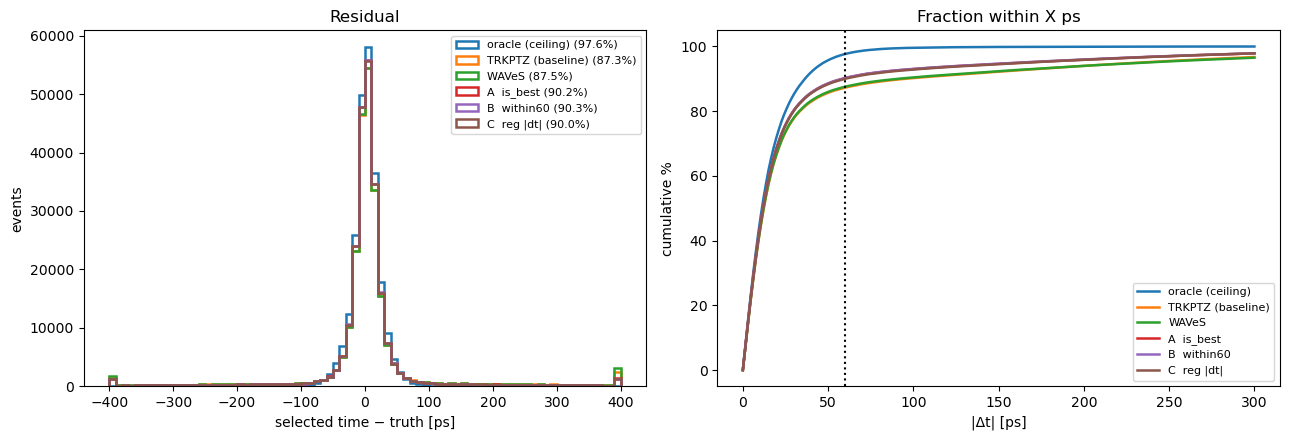

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-400, 400, 81)
for name, col, hib in ROWS:
    s = test[col].fillna(-np.inf if hib else np.inf)
    idx = s.groupby([test[c] for c in EVT], sort=False)
    idx = idx.idxmax() if hib else idx.idxmin()
    sel = test.loc[idx.to_numpy()]
    ax[0].hist(np.clip(sel["delta_t"], bins[0], bins[-1]), bins=bins,
               histtype="step", lw=1.8, label=f"{name} ({(sel['abs_dt']<PASS_PS).mean()*100:.1f}%)")
    x = np.linspace(0, 300, 200)
    ax[1].plot(x, [100*(sel["abs_dt"] < v).mean() for v in x], lw=1.8, label=name)
ax[0].set_xlabel("selected time − truth [ps]"); ax[0].set_ylabel("events")
ax[0].legend(fontsize=8); ax[0].set_title("Residual")
ax[1].axvline(PASS_PS, ls=":", c="k"); ax[1].set_xlabel("|Δt| [ps]")
ax[1].set_ylabel("cumulative %"); ax[1].legend(fontsize=8)
ax[1].set_title("Fraction within X ps")
plt.tight_layout(); plt.show()

## 11. Phase 2 — per-track P(HS), aggregated to a cluster score

The cluster-level model closes only **14% of the gap on Z+jets**, which is where 26 of the
~30 available points sit. This section attacks it from the other side.

**Idea.** Every track carries a truth label (`truth_is_hs`), so the `tracks` tree has ~23M labelled
examples versus 782k events — nearly two orders of magnitude more training signal. Learn
`P(HS | track)`, then score a cluster by `Σ pT·P(HS)`.

That expression is exactly what WAVeS approximates by hand with `pT·pT_jet/ΔR` — WAVeS is guessing
at `P(HS)` using jet proximity as a proxy, which is why it works on VBF (forward jets *are* HS) and
fails on Z+jets (forward jets are pileup). Learning it should remove that topology dependence.

Four engineering points:
- **Memory**: the track tree is far too big to hold at once, so we stream it with `uproot.iterate`
  and only ever keep batch-level aggregates.
- **Per-sample quotas.** ⚠️ The first version of this cell streamed the files in order and
  `break`-ed at `TRACK_TRAIN_MAX`. VBF alone supplies ~12.5M train-fold track rows against a 4M
  cap, so **the track model was trained on 100% VBF tracks** and then applied to Z+jets and dijet —
  precisely the topology mismatch this section exists to remove. Now each sample gets its own
  quota and the per-sample composition is printed, so a repeat is visible rather than silent.
- **Batch-safe aggregation**: a cluster's tracks can straddle a batch boundary, so we accumulate
  only **sums and counts** (which combine across batches) and derive means at the end. Never `mean`
  or `median` per batch.
- **No leakage**: the track model is trained on tracks from **train-fold events only**, reusing the
  same event-level split, so the cluster-level evaluation stays honest.

In [18]:
TRACK_LABEL = "truth_is_hs"
TRACK_FEATURES = ["pt", "eta", "theta", "z0", "d0", "qOverP",
                  "sigma_z0", "sigma_d0", "sigma_qOverP",
                  "time", "timeRes", "time_valid", "quality", "nhgtd_hits",
                  "z0_pull_pv", "t_pull_cluster",
                  "dr_nearest_fwdjet", "pt_nearest_fwdjet", "is_ghost_of_nearest",
                  "is_lepton", "cluster_time", "cluster_delta_z"]
KEY = ["sample_id", "event_num", "cluster_idx"]
# TRACK_FEATURES is an explicit allowlist, so truth columns cannot sneak in the way
# they can on the cluster side -- but assert it anyway, including the pre-rename
# alias (the tracks tree carries nhgtd_primary / truth_nhgtd_primary).
_bad = [f for f in TRACK_FEATURES if f.startswith("truth_") or f in set(TRUTH_ALIASES)]
assert not _bad, f"TRUTH IN TRACK FEATURES: {_bad}"

READ = sorted(set(TRACK_FEATURES + KEY + [TRACK_LABEL]))
TRACK_TRAIN_MAX = 4_000_000     # total across samples; raise if you have headroom
STEP = "300 MB"

# Stream each sample SEPARATELY with its own quota. The previous version iterated
# a single concatenated path list and broke at the global cap, which -- because vbf
# is listed first and carries ~12.5M train-fold track rows on its own -- trained the
# P(HS) model on vbf tracks exclusively. Since the whole point is to remove the
# topology dependence that sinks WAVeS on Z+jets, that quietly defeated the section.
SAMPLE_PATHS = {name: f"{p}:tracks" for name, p in FILES.items()}
QUOTA = TRACK_TRAIN_MAX // max(1, len(SAMPLE_PATHS))
fold  = ev.set_index(EVT)["fold"]                    # same split as the cluster model

def batch_fold(b):
    return fold.reindex(pd.MultiIndex.from_arrays(
        [b["sample_id"], b["event_num"]])).to_numpy()

# ---- pass 1: per-sample training subsample, TRAIN-fold events only ---------
chunks = []
print(f"per-sample quota: {QUOTA:,} rows")
for name, path in SAMPLE_PATHS.items():
    n = 0
    for b in uproot.iterate(path, READ, library="pd", step_size=STEP):
        b = b[batch_fold(b) < 0.7]
        if len(b) == 0:
            continue
        if n + len(b) > QUOTA:
            b = b.sample(max(0, QUOTA - n), random_state=RANDOM)
        if len(b):
            chunks.append(b); n += len(b)
        if n >= QUOTA:
            break
    got = "quota met" if n >= QUOTA else "ALL available (under quota)"
    print(f"  {name:6s} {n:>9,} rows   {got}")
trk = pd.concat(chunks, ignore_index=True); del chunks

print(f"\ntrack training rows: {len(trk):,}   P(HS) prior = {trk[TRACK_LABEL].mean():.3f}")
print("composition and per-sample prior (both should be non-degenerate):")
comp = trk.groupby("sample_id").agg(rows=(TRACK_LABEL, "size"), prior=(TRACK_LABEL, "mean"))
comp["frac"] = comp["rows"] / len(trk)
print(comp)
assert len(comp) == len(SAMPLE_PATHS), \
    f"track model sees only {len(comp)} of {len(SAMPLE_PATHS)} samples -- quota logic broke"

mT = HistGradientBoostingClassifier(**COMMON).fit(trk[TRACK_FEATURES], trk[TRACK_LABEL])
print(f"\niterations used: {mT.n_iter_}")

# Flat path list for the aggregation pass in 11b (which must read EVERY sample,
# unlike the quota-limited training pass above).
ALL_TRACK_PATHS = list(SAMPLE_PATHS.values())

# Staleness guard. 11b/11c consume `agg`, which is derived from THIS model; if the
# model is refit and 11b is not re-run, 11c silently reports the old model's numbers
# from a stale `agg` still in the kernel. That already happened once (run 3: cell 24
# re-executed at In[27] while the aggregation sat at In[24], so the "fixed" Phase-2
# numbers were still the vbf-only model's). Bump on every fit; 11b records it and
# 11c asserts they match.
MT_FIT_ID = globals().get("MT_FIT_ID", 0) + 1
print(f"MT_FIT_ID = {MT_FIT_ID}  (re-run 11b before 11c)")

per-sample quota: 1,333,333 rows  vbf    1,333,333 rows   quota met  zjets  1,226,314 rows   ALL available (under quota)  dijet  1,333,333 rows   quota met

track training rows: 3,892,980   P(HS) prior = 0.287
composition and per-sample prior (both should be non-degenerate):
              rows     prior      frac
sample_id                             
0.0        1333333  0.314821  0.342497
1.0        1226314  0.206923  0.315006
2.0        1333333  0.332753  0.342497
iterations used: 1612
MT_FIT_ID = 2  (re-run 11b before 11c)

### 11b. Stream over all tracks and aggregate per cluster

Only sum-like accumulators, so batch boundaries splitting a cluster are harmless.

In [19]:
parts = []
for b in uproot.iterate(ALL_TRACK_PATHS, READ, library="pd", step_size=STEP):
    p = mT.predict_proba(b[TRACK_FEATURES])[:, 1]
    b = b.assign(_p=p, _ptp=b["pt"] * p, _hi=(p > 0.5).astype(np.int8))
    parts.append(b.groupby(KEY, sort=False)
                  .agg(sum_ptp=("_ptp", "sum"), sum_p=("_p", "sum"),
                       max_p=("_p", "max"), n_hi=("_hi", "sum"),
                       sum_pt=("pt", "sum"), n=("_p", "size")))
agg = pd.concat(parts).groupby(level=[0, 1, 2]).agg(
    sum_ptp=("sum_ptp", "sum"), sum_p=("sum_p", "sum"), max_p=("max_p", "max"),
    n_hi=("n_hi", "sum"), sum_pt=("sum_pt", "sum"), n=("n", "sum")).reset_index()
del parts

# derived (safe: built from combinable sums/counts, not per-batch means)
agg["phs_sum_ptp"]  = agg["sum_ptp"]                       # the WAVeS analogue
agg["phs_mean"]     = agg["sum_p"] / agg["n"]
agg["phs_ptw_mean"] = agg["sum_ptp"] / agg["sum_pt"].replace(0, np.nan)
agg["phs_max"]      = agg["max_p"]
agg["phs_n_hi"]     = agg["n_hi"]
PHS = ["phs_sum_ptp", "phs_mean", "phs_ptw_mean", "phs_max", "phs_n_hi"]
AGG_FIT_ID = MT_FIT_ID          # stamp: which track model produced this agg
print(f"aggregated {len(agg):,} clusters   (from MT_FIT_ID={AGG_FIT_ID})")
print(agg[PHS].describe().T[["mean", "50%", "max"]])

aggregated 4,411,382 clusters   (from MT_FIT_ID=2)                  mean       50%         max
phs_sum_ptp   6.260959  0.519068  259.796241
phs_mean      0.227393  0.128420    0.999689
phs_ptw_mean  0.260787  0.133080    0.999689
phs_max       0.370059  0.231508    0.999719
phs_n_hi      1.388438  0.000000   44.000000

### 11c. Does it select better?

Two questions: is `Σ pT·P(HS)` a good selector **on its own** (vs TRKPTZ and the Phase-1 model),
and does adding the P(HS) aggregates as **features** improve the cluster model?

In [20]:
assert globals().get("AGG_FIT_ID") == MT_FIT_ID, (
    f"STALE agg: built from MT_FIT_ID={globals().get('AGG_FIT_ID')} but the current "
    f"track model is MT_FIT_ID={MT_FIT_ID}. Re-run 11b."
)

test2 = test.merge(agg[KEY + PHS], on=KEY, how="left")
gb2   = test2.groupby(EVT, sort=False)
for c in PHS:
    mx = gb2[c].transform("max")
    test2[f"{c}_ratio_to_max"] = np.where(np.abs(mx) > 0, test2[c] / mx, np.nan)
train2 = train.merge(agg[KEY + PHS], on=KEY, how="left")
gb3    = train2.groupby(EVT, sort=False)
for c in PHS:
    mx = gb3[c].transform("max")
    train2[f"{c}_ratio_to_max"] = np.where(np.abs(mx) > 0, train2[c] / mx, np.nan)

# Per sample, not just pooled: vbf is 79% of the test set and is near-saturated,
# so a pooled row is dominated by the sample with nothing left to win. Everything
# interesting about P(HS) is whether it beats TRKPTZ on ZJETS specifically.
STANDALONE = [("TRKPTZ", "trkptz_score"), ("WAVeS", "waves_score"),
              ("Phase-1 model B", "scoreB"),
              ("P(HS): sum pT*P [WAVeS analogue]", "phs_sum_ptp"),
              ("P(HS): pT-weighted mean", "phs_ptw_mean"),
              ("P(HS): max", "phs_max")]
S_IDS = sorted(test2["sample_id"].unique())
S_NAMES = [SAMPLE_NAME.get(s, s) for s in S_IDS]
print("=== standalone selectors (test) ===")
print(f"  {'selector':34s}" + "".join(f"{n:>10s}" for n in S_NAMES) + f"{'POOLED':>10s}")
print("  " + "-" * (34 + 10 * (len(S_IDS) + 1)))
for nm, col in STANDALONE:
    per = [select_metric(test2[test2.sample_id == s], col)[0] for s in S_IDS]
    print(f"  {nm:34s}" + "".join(f"{v:9.1f}%" for v in per)
          + f"{select_metric(test2, col)[0]:9.1f}%")
orc = [select_metric(test2[test2.sample_id == s], "abs_dt", False)[0] for s in S_IDS]
print(f"  {'oracle (ceiling)':34s}" + "".join(f"{v:9.1f}%" for v in orc)
      + f"{select_metric(test2, 'abs_dt', False)[0]:9.1f}%")

print("\n=== cluster model WITH P(HS) features ===")
featP = feat + PHS + [f"{c}_ratio_to_max" for c in PHS]
mP = HistGradientBoostingClassifier(**COMMON).fit(train2[featP], train2["is_best"],
                                                  sample_weight=sample_weights(train2))
test2["scoreP"] = mP.predict_proba(test2[featP])[:, 1]
for lbl, frame, sub in ([("ALL", test2, None)] +
                        [(SAMPLE_NAME.get(s, s), test2, s) for s in sorted(test2.sample_id.unique())]):
    f = frame if sub is None else frame[frame.sample_id == sub]
    b  = select_metric(f, "trkptz_score")[0]
    p1 = select_metric(f, "scoreB")[0]
    p2 = select_metric(f, "scoreP")[0]
    o  = select_metric(f, "abs_dt", False)[0]
    print(f"  {lbl:8s} TRKPTZ {b:5.1f}%  ph1 {p1:5.1f}%  ph1+P(HS) {p2:5.1f}%  "
          f"oracle {o:5.1f}%   (+{p2-p1:.1f} from P(HS))")

=== standalone selectors (test) ===
  selector                        core<60ps
  TRKPTZ                              87.3%  WAVeS                               87.5%  Phase-1 model B                     90.3%  P(HS): sum pT*P  [WAVeS analogue]      89.0%  P(HS): pT-weighted mean             74.2%

=== cluster model WITH P(HS) features ===  ALL      TRKPTZ  87.3%  ph1  90.3%  ph1+P(HS)  90.4%  oracle  97.6%   (+0.2 from P(HS))  vbf      TRKPTZ  90.1%  ph1  93.0%  ph1+P(HS)  93.1%  oracle  98.2%   (+0.1 from P(HS))
  zjets    TRKPTZ  62.1%  ph1  66.3%  ph1+P(HS)  67.1%  oracle  92.2%   (+0.9 from P(HS))  dijet    TRKPTZ  87.0%  ph1  89.5%  ph1+P(HS)  89.6%  oracle  97.8%   (+0.1 from P(HS))

## Next steps

**Decision gate:** does any of A/B/C beat TRKPTZ on the §7 table, and does the §8 matrix hold up
off-diagonal? If yes → Phase 2. If no, the tabular features are not carrying the signal and the
per-track route below is the better bet regardless.

1. **Per-track P(HS) model** (highest value). The exporter's `tracks` tree has ~30 rows/event with
   `truth_is_hs` — millions of labeled examples instead of ~67k events. Train `P(HS|track)`, then
   score clusters as `Σ pT·P(HS)`. That is the *learned* form of exactly what WAVeS hard-codes as
   `pT_jet/ΔR`, which is why WAVeS is topology-dependent and this should not be.
2. **Deep Sets over clusters** — permutation-invariant, scores each cluster conditioned on its
   competitors. The principled version of the §4 hand-built context features.
3. **Abstain output** — the ~13% of events with no good cluster are currently unwinnable noise.
   A confidence/margin cut gives the "don't trust this vertex time" flag downstream RpT wants.
4. **Deployment**: inference runs inside `TTreeProcessorMT` over millions of events (~µs/event,
   thread-safe). GBDT or a small MLP via ONNX Runtime is fine; note TMVA is deliberately excluded
   from this build (`CMakeLists.txt`), so ONNX is the path.